In [1]:
# 2D Heat Map - Monthly Stream Temperature Contour

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os


In [2]:
def plot_monthly_water_temp_contour(xr_data, time_slice, x_slice, save_fp=None, save_dpi=600):
    
    import calendar
    
    # 1) Select the time & x-range
    T = xr_data['T'].sel(time=time_slice, x=x_slice)

    # 2) Group by calendar month and average over time
    #    Result dims: (month=1..12, x)
    T_monthly = T.groupby('time.month').mean(dim='time')

    # 3) Extract the numeric arrays for plotting
    months = T_monthly['month'].values               
    x_pos  = T_monthly['x'].values                    
    Z      = T_monthly.values                         

    # 4) Build the grid
    M, X = np.meshgrid(months, x_pos, indexing='xy')  # X: x_pos×month

    # 5) Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Filled contours
    cf = ax.contourf(M, X, Z.T, levels=20, cmap='RdBu_r', extend='both')
    # Overlay contour lines
    cs = ax.contour(M, X, Z.T, levels=10, colors='k', linewidths=0.5)
    ax.clabel(cs, fmt='%1.1f', fontsize=12)

    # Colorbar
    cbar = fig.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label(r'$\mathrm{T_s}$ (°C)', fontsize=12)  

    # 6) Format axes
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('X (m)', fontsize=12)

    # Replace month numbers with names
    ax.set_xticks(months)
    ax.set_xticklabels([calendar.month_abbr[m] for m in months], fontsize=12)

    # Add a grid
    ax.grid(True, linestyle='--', alpha=0.4)

    # Title
    start, stop = pd.to_datetime(time_slice.start), pd.to_datetime(time_slice.stop)
    # ax.set_title

    plt.tight_layout()
    if save_fp:
        fig.savefig(
            save_fp,
            dpi=save_dpi,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
    plt.show()

In [3]:


# Load DTS dataset
file = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All\Filetered DTS NEW FULL.nc"
data = xr.open_dataset(file, engine='netcdf4')

print(f"X range: {data.x.min().values} to {data.x.max().values} m")
print(f"Temperature range: {data.T.min().values:.2f} to {data.T.max().values:.2f} °C")

X range: 60.603 to 1939.633 m
Temperature range: 0.30 to 27.36 °C


In [4]:
# Check how many temperature values are below 0°C
below_zero = (data.T < 0).sum().values
total_values = data.T.size
percentage = (below_zero / total_values) * 100

print(f"Number of temperature values below 0°C: {below_zero:,}")
print(f"Total number of temperature values: {total_values:,}")
print(f"Percentage below 0°C: {percentage:.2f}%")
print(f"\nMinimum temperature: {data.T.min().values:.2f}°C")
print(f"Maximum temperature: {data.T.max().values:.2f}°C")


Number of temperature values below 0°C: 0
Total number of temperature values: 53,327,529
Percentage below 0°C: 0.00%

Minimum temperature: 0.30°C
Maximum temperature: 27.36°C


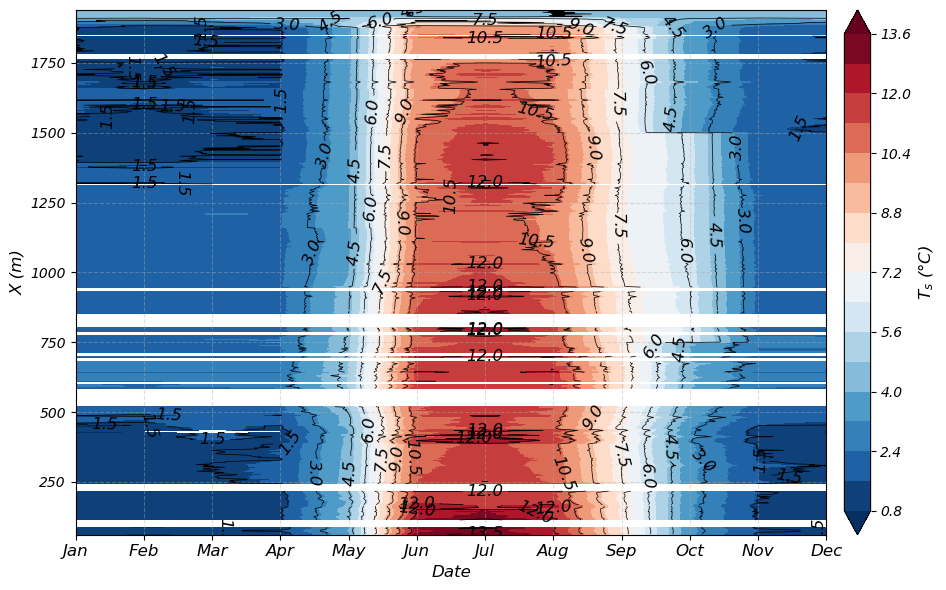

Saved PNG: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\monthly_water_temp_contour.png


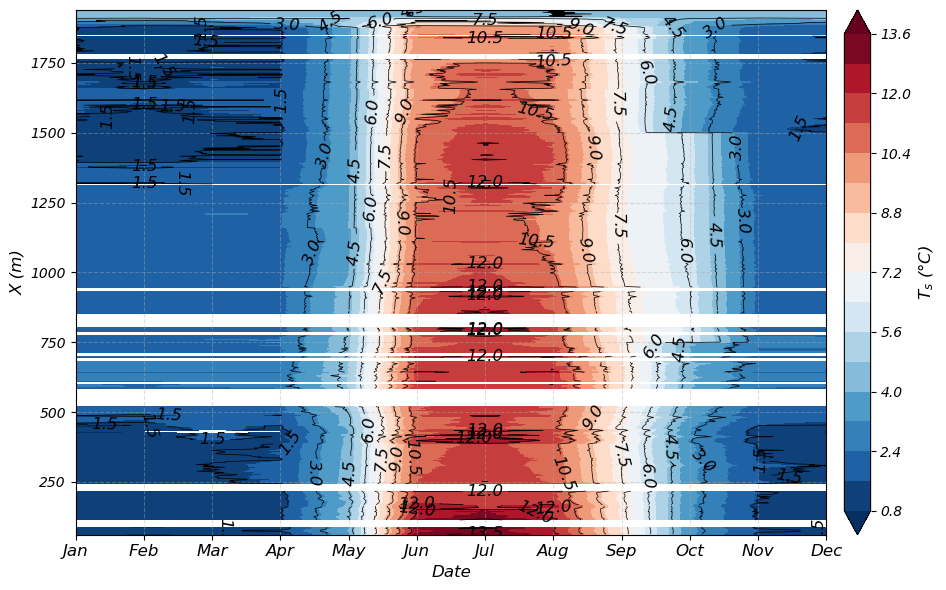

Saved PDF: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\monthly_water_temp_contour.pdf


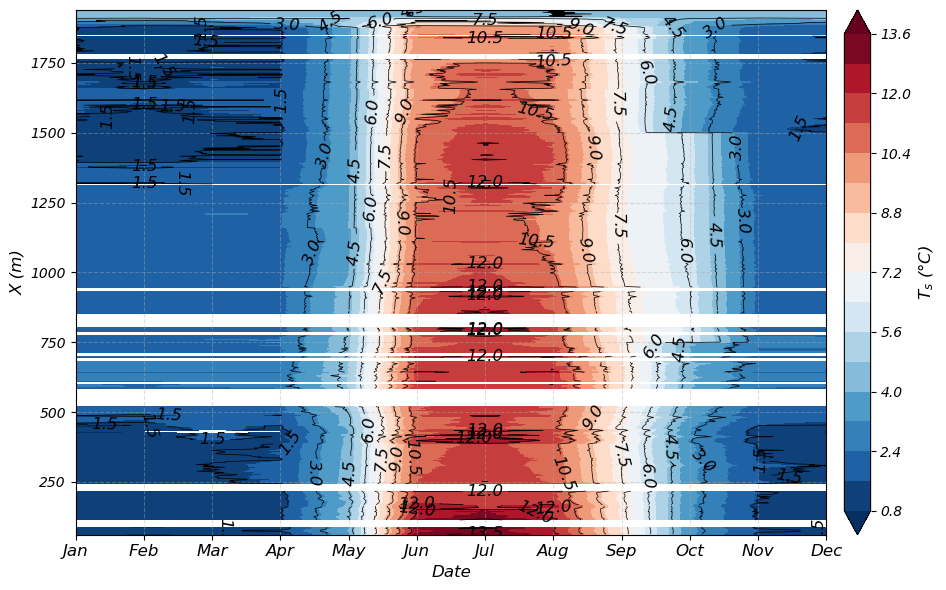

Saved SVG: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\monthly_water_temp_contour.svg


In [10]:
time_slice = slice("2021-06-01", "2023-12-30")
x_slice = slice(50, 2000)

_out_article_dir = (
    r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk"
    r"\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025"
    r"\Final Final Revision plots with SW"
)

os.makedirs(_out_article_dir, exist_ok=True)

# ---------------- PNG ----------------
_out_runoff_png = os.path.join(
    _out_article_dir,
    "monthly_water_temp_contour.png"
)

plot_monthly_water_temp_contour(
    data,
    time_slice,
    x_slice,
    save_fp=_out_runoff_png,
    save_dpi=600
)

print("Saved PNG:", _out_runoff_png)

# ---------------- PDF ----------------
_out_runoff_pdf = os.path.join(
    _out_article_dir,
    "monthly_water_temp_contour.pdf"
)

plot_monthly_water_temp_contour(
    data,
    time_slice,
    x_slice,
    save_fp=_out_runoff_pdf,
    save_dpi=600
)

print("Saved PDF:", _out_runoff_pdf)

# ---------------- SVG ----------------
_out_runoff_svg = os.path.join(
    _out_article_dir,
    "monthly_water_temp_contour.svg"
)

plot_monthly_water_temp_contour(
    data,
    time_slice,
    x_slice,
    save_fp=_out_runoff_svg,
    save_dpi=600
)

print("Saved SVG:", _out_runoff_svg)